# Física Computacional  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib widget

### Ejercicio 1

a)  
Para determinar las ecuaciones de movimiento, aplicamos la Segunda Ley de Newton en forma vectorial:$$\vec{F}_{neta} = m \vec{a}$$En este sistema, la fuerza neta es la suma de la fuerza restauradora del oscilador y la fuerza de fricción:$$\vec{F}_{neta} = \vec{F}_{rest} + \vec{f}_{fric}$$Donde los parámetros dados son $m = 1$ y $k = 1$.  
  
Fuerza Restauradora:$\vec{F}_{rest} = -k \vec{r} = -(1)(x\hat{i} + y\hat{j})$  
Fuerza de Fricción:
Depende de la rapidez $v = |\vec{v}| = \sqrt{\dot{x}^2 + \dot{y}^2}$.  
Si $v \leq 1$:  
$\vec{f}_{fric} = -\gamma \vec{v} = -0.15(\dot{x}\hat{i} + \dot{y}\hat{j})$  
Si $v > 1$:  
$\vec{f}_{fric} = -\mu v^2 \hat{v} = -\mu v \vec{v} = -0.25 \sqrt{\dot{x}^2 + \dot{y}^2} (\dot{x}\hat{i} + \dot{y}\hat{j})$  
   
Dado que $m = 1$, la aceleración $\vec{a} = (\ddot{x}, \ddot{y})$ es igual a la fuerza neta.  
Las ecuaciones resultantes son:  
Caso 1: Para rapidez baja ($\sqrt{\dot{x}^2 + \dot{y}^2} \leq 1$)$$ \ddot{x} + 0.15\dot{x} + x = 0 $$$$ \ddot{y} + 0.15\dot{y} + y = 0 $$  
Caso 2: Para rapidez alta ($\sqrt{\dot{x}^2 + \dot{y}^2} > 1$)$$ \ddot{x} + 0.25 \left( \sqrt{\dot{x}^2 + \dot{y}^2} \right) \dot{x} + x = 0 $$$$ \ddot{y} + 0.25 \left( \sqrt{\dot{x}^2 + \dot{y}^2} \right) \dot{y} + y = 0 $$

In [2]:
# Parámetros
k = 1.0
m = 1.0
gamma = 0.15
mu = 0.25

def ecuaciones_movimiento(t, estado):
    
    x, y, vx, vy = estado
    r = np.array([x, y])
    v = np.array([vx, vy])
    rapidez = np.linalg.norm(v)
    
    # Fuerza restauradora
    f_rest = -k * r
    
    # Fuerza de fricción según la condición de rapidez
    if rapidez <= 1.0:
        f_fric = -gamma * v
    else:
        f_fric = -mu * rapidez * v
        
    # Como m=1, a = F_total
    aceleracion = (f_rest + f_fric) / m
    
    return [vx, vy, aceleracion[0], aceleracion[1]]


b)  
El sistema original de dos ecuaciones de segundo orden ($\ddot{x}$ y $\ddot{y}$) se trata numéricamente como un sistema de cuatro ecuaciones de primer orden. El estado del sistema en cada paso está definido por el vector posición $\vec{r}$ y el vector velocidad $\vec{v}$.  
Se itera sobre $n = 0, 1, ..., 11$. Esto genera 12 vectores de velocidad inicial que apuntan en diferentes direcciones alrededor de un círculo (cada 30 grados), partiendo todos desde el mismo punto $(0, 1)$.  
El código evalúa la condición de rapidez en cada paso de RK4. Esto es crucial porque la partícula puede empezar con rapidez $> 1$ (fricción cuadrática) y, a medida que pierde energía, pasar al régimen de rapidez $\leq 1$ (fricción lineal). El método RK4 maneja estas transiciones de forma suave.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros del problema (del enunciado)
m = 1.0
k = 1.0
gamma = 0.15
mu = 0.25
dt = 0.05  # Paso de tiempo
t_max = 20 # Tiempo total de simulación para visualizar la oscilación

# 2. Definición de la aceleración (Ecuaciones del inciso a)
def calcular_aceleracion(r, v):
    rapidez = np.sqrt(np.dot(v, v))
    f_rest = -k * r
    
    if rapidez <= 1.0:
        f_fric = -gamma * v
    else:
        # f = -mu * v^2 * unitario(v) = -mu * v * vector_v
        f_fric = -mu * rapidez * v
        
    return (f_rest + f_fric) / m

# 3. Algoritmo de Runge-Kutta de 4to Orden (RK4)
def rk4_step(r, v, dt):
    # k1
    k1_v = calcular_aceleracion(r, v)
    k1_r = v
    
    # k2
    k2_v = calcular_aceleracion(r + 0.5*dt*k1_r, v + 0.5*dt*k1_v)
    k2_r = v + 0.5*dt*k1_v
    
    # k3
    k3_v = calcular_aceleracion(r + 0.5*dt*k2_r, v + 0.5*dt*k2_v)
    k3_r = v + 0.5*dt*k2_v
    
    # k4
    k4_v = calcular_aceleracion(r + dt*k3_r, v + dt*k3_v)
    k4_r = v + dt*k3_v
    
    # Actualización de estado
    v_next = v + (dt/6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
    r_next = r + (dt/6.0) * (k1_r + 2*k2_r + 2*k3_r + k4_r)
    
    return r_next, v_next

# 4. Ejecución de la simulación para las 12 condiciones iniciales
r0 = np.array([0.0, 1.0])
plt.figure(figsize=(10, 8))

for n in range(12):
    theta = n * np.pi / 6
    v0 = np.array([2 * np.cos(theta), 2 * np.sin(theta)])
    
    # Listas para almacenar la trayectoria
    x_hist, y_hist = [r0[0]], [r0[1]]
    r, v = r0, v0
    
    # Simulación temporal
    for _ in range(int(t_max/dt)):
        r, v = rk4_step(r, v, dt)
        x_hist.append(r[0])
        y_hist.append(r[1])
    
    plt.plot(x_hist, y_hist, label=f'n={n} (θ={n*30}°)')

# 5. Formato de la gráfica
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlabel("Posición x")
plt.ylabel("Posición y")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.show()

c)  
Se implementa $E = \frac{1}{2}m|\vec{v}|^2 + \frac{1}{2}k|\vec{r}|^2$. Esta magnitud es estrictamente decreciente debido a que el trabajo realizado por la fricción siempre es negativo.  
El bucle while evalúa en cada paso si la energía actual ha cruzado el umbral de $0.3 \times E_{inicial}$. Esto permite que cada simulación dure un tiempo distinto dependiendo de cuánta fricción experimente la partícula según su dirección inicial.

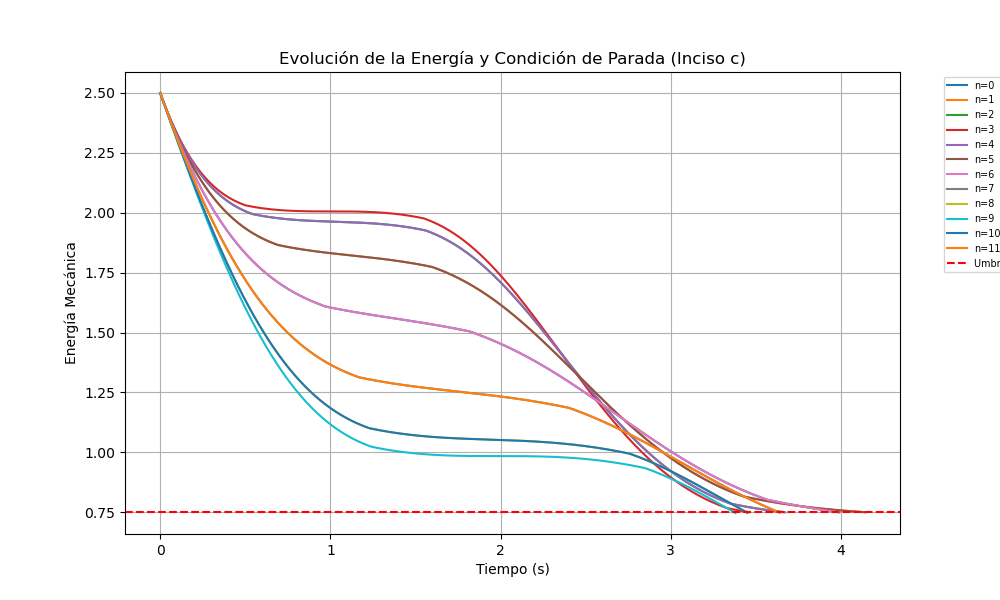

In [4]:
# Parámetros físicos constantes
m = 1.0
k = 1.0
gamma = 0.15
mu = 0.25

def calcular_energia(r, v):
    """
    Calcula la energía mecánica total (Cinética + Potencial).
    E = (1/2)mv^2 + (1/2)kr^2
    """
    cinetica = 0.5 * m * np.dot(v, v)
    potencial = 0.5 * k * np.dot(r, r)
    return cinetica + potencial

def aceleracion(r, v):
    """Ecuaciones de movimiento del inciso (a)"""
    rapidez = np.linalg.norm(v)
    f_rest = -k * r
    if rapidez <= 1.0:
        f_fric = -gamma * v
    else:
        f_fric = -mu * rapidez * v
    return (f_rest + f_fric) / m

def rk4_step(r, v, dt):
    """Paso elemental de Runge-Kutta 4to orden"""
    k1_v = aceleracion(r, v)
    k1_r = v
    k2_v = aceleracion(r + 0.5*dt*k1_r, v + 0.5*dt*k1_v)
    k2_r = v + 0.5*dt*k1_v
    k3_v = aceleracion(r + 0.5*dt*k2_r, v + 0.5*dt*k2_v)
    k3_r = v + 0.5*dt*k2_v
    k4_v = aceleracion(r + dt*k3_r, v + dt*k3_v)
    k4_r = v + dt*k3_v
    
    r_new = r + (dt/6.0) * (k1_r + 2*k2_r + 2*k3_r + k4_r)
    v_new = v + (dt/6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
    return r_new, v_new

# --- Simulación con condición de parada del 30% ---
# Para asegurar un error < 0.1% en RK4, un dt de 0.01 es suficiente para este sistema
dt = 0.01 
r0 = np.array([0.0, 1.0])
resultados_inciso_c = []

plt.figure(figsize=(10, 6))

for n in range(12):
    theta = n * np.pi / 6
    v0 = np.array([2 * np.cos(theta), 2 * np.sin(theta)])
    
    r, v = r0, v0
    e_inicial = calcular_energia(r, v)
    
    historia_energia = [e_inicial]
    tiempos = [0]
    t = 0
    
    # Condición de parada: Energía < 30% del valor inicial
    while True:
        r, v = rk4_step(r, v, dt)
        t += dt
        e_actual = calcular_energia(r, v)
        
        historia_energia.append(e_actual)
        tiempos.append(t)
        
        if e_actual < 0.3 * e_inicial:
            break
            
    plt.plot(tiempos, historia_energia, label=f'n={n}')
    resultados_inciso_c.append(tiempos[-1]) # Guardamos el tiempo de parada

plt.axhline(y=0.3 * e_inicial, color='r', linestyle='--', label='Umbral 30%')
plt.title("Evolución de la Energía y Condición de Parada (Inciso c)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Energía Mecánica")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
plt.grid(True)
plt.show()

d)  
el momento angular no se conserva (no es una línea recta horizontal). Esto tiene sentido porque la fuerza de fricción no es una fuerza central, sino que siempre se opone al vector velocidad.

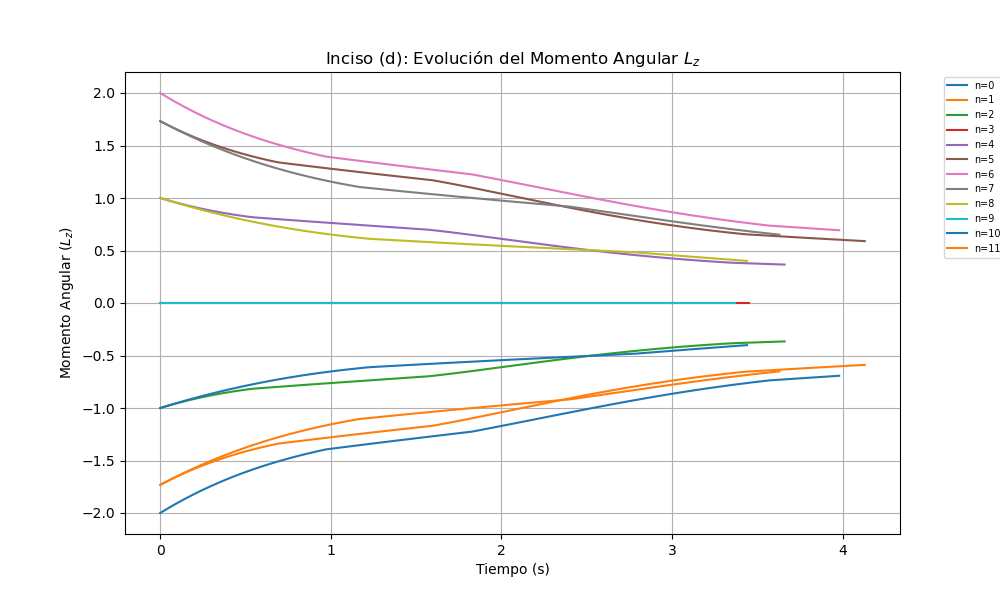

In [5]:
plt.figure(figsize=(10, 6))

for n in range(12):
    theta = n * np.pi / 6
    v0 = np.array([2 * np.cos(theta), 2 * np.sin(theta)])
    r, v = r0, v0
    
    L_hist = []
    T_hist = []
    t = 0
    
    # Usamos la misma lógica de parada del inciso c
    e_inicial = calcular_energia(r, v)
    while True:
        # Momento angular L = x*vy - y*vx (m=1)
        Lz = r[0]*v[1] - r[1]*v[0]
        L_hist.append(Lz)
        T_hist.append(t)
        
        r, v = rk4_step(r, v, dt)
        t += dt
        if calcular_energia(r, v) < 0.3 * e_inicial:
            break
            
    plt.plot(T_hist, L_hist, label=f'n={n}')

plt.title("Inciso (d): Evolución del Momento Angular $L_z$")
plt.xlabel("Tiempo (s)")
plt.ylabel("Momento Angular ($L_z$)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='x-small')
plt.grid(True)
plt.show()

e)  
La curva comienza en $(x=0, p_x \approx 1.73)$. Esto es consistente con la condición inicial para $n=1$, donde $x_0=0$ y $v_{x0} = 2 \cos(\pi/6) = \sqrt{3} \approx 1.732$.  
El "radio" de la trayectoria va disminuyendo, aal llegar al final de la curva (cuando la simulación se detiene por la condición del 30% de energía), la partícula está más cerca del origen y tiene menos momento que al principio.

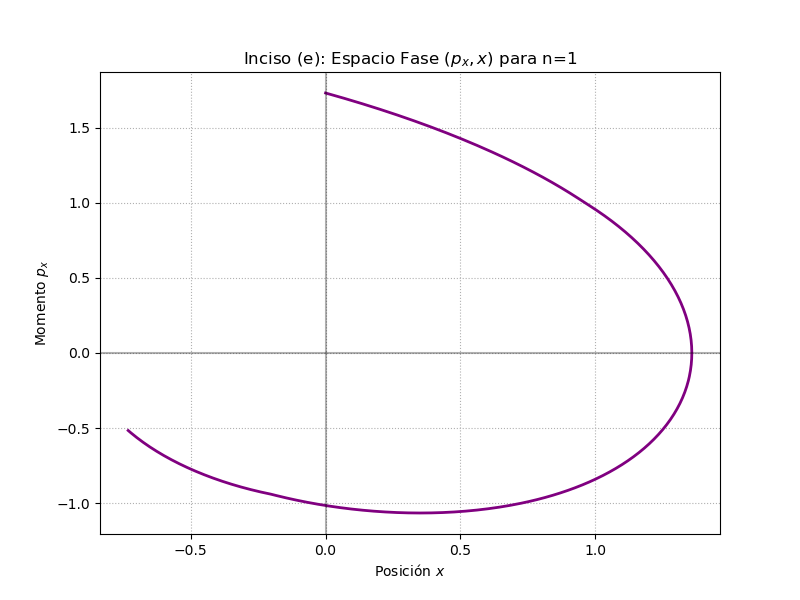

In [6]:
n_elegido = 1
theta = n_elegido * np.pi / 6
v0 = np.array([2 * np.cos(theta), 2 * np.sin(theta)])
r, v = r0, v0

x_pos = []
px_mom = []
e_inicial = calcular_energia(r, v)


while True:
    x_pos.append(r[0])
    px_mom.append(m * v[0]) # p = m * v
    
    r, v = rk4_step(r, v, dt)
    if calcular_energia(r, v) < 0.3 * e_inicial:
        break

plt.figure(figsize=(8, 6))
plt.plot(x_pos, px_mom, color='purple', lw=2)
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)
plt.title(f"Inciso (e): Espacio Fase ($p_x, x$) para n={n_elegido}")
plt.xlabel("Posición $x$")
plt.ylabel("Momento $p_x$")
plt.grid(True, linestyle=':')
plt.show()

### Ejercicio 2

a)  
El sistemaa consta de una partícula anclada en el origen y una móvil, ambas con masa $m$ y carga $q$. Las fuerzas que interactúan son:  
Fuerza de tipo resorte: $\vec{F}_{res} = -k\vec{r}$, que es una fuerza atractiva hacia el origen.  
Fuerza de Coulomb: $\vec{F}_{Coul} = \frac{1}{4\pi\epsilon_0} \frac{q^2}{r^2} \hat{r}$, que es una fuerza repulsiva desde el origen ya que ambas cargas tienen el mismo signo $q > 0$.  
La fuerza total neta es una fuerza central, lo que significa que el momento angular se conserva y el movimiento ocurre en un plano. Podemos definir un potencial efectivo $V_{eff}(r)$ para un momento angular $L$ dado:  
$$V_{eff}(r) = \frac{L^2}{2mr^2} + \frac{1}{2}kr^2 + \frac{1}{4\pi\epsilon_0}\frac{q^2}{r}$$  

El sistema puede tener órbitas cerradas bajo condiciones específicas.  
Para que existan órbitas cerradas en un potencial central, se deben cumplir generalmente dos condiciones:  
-El potencial efectivo debe tener un mínimo local donde la partícula pueda quedar "atrapada" en un movimiento radial acotado ($r_{min} \leq r \leq r_{max}$).  
-Teorema de Bertrand: Este teorema establece que las únicas fuerzas centrales que producen órbitas cerradas para todas las condiciones iniciales acotadas son la fuerza de Hooke ($F \propto r$) y la fuerza de gravedad/Coulomb ($F \propto 1/r^2$).  

  
Dado que nuestro sistema es una combinación de ambas fuerzas, el sistema no producirá órbitas cerradas para cualquier condición inicial. Sin embargo, existen dos casos particulares donde sí tendremos órbitas cerradas:  
Órbitas circulares: Si la partícula se lanza con la velocidad exacta para que la fuerza centrípeta iguale a la suma de las fuerzas de resorte y Coulomb en un radio donde $\frac{dV_{eff}}{dr} = 0$.  
Órbitas con frecuencias conmensurables: Si la frecuencia de oscilación radial y la frecuencia angular tienen una razón racional.  

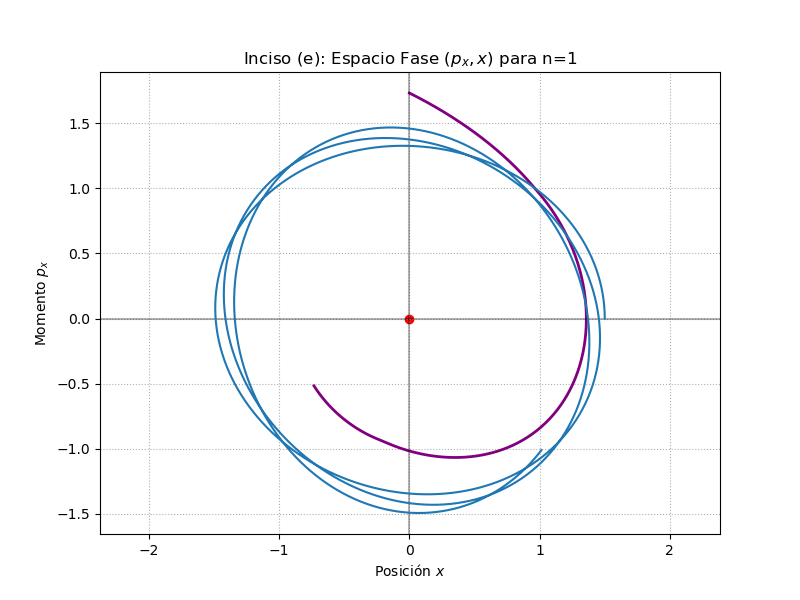

In [7]:
m, k, q_factor = 1.0, 1.0, 0.5  # q_factor engloba q^2 / 4pieps0

def aceleracion(r):
    norm_r = np.linalg.norm(r)
    # Fuerza de resorte  + Fuerza de Coulomb 
    f_total = -k * r + (q_factor / norm_r**3) * r
    return f_total / m

def rk4_step(r, v, dt):
    k1_v = aceleracion(r)
    k1_r = v
    k2_v = aceleracion(r + 0.5*dt*k1_r)
    k2_r = v + 0.5*dt*k1_v
    k3_v = aceleracion(r + 0.5*dt*k2_r)
    k3_r = v + 0.5*dt*k2_v
    k4_v = aceleracion(r + dt*k3_r)
    k4_r = v + dt*k3_v
    return r + (dt/6)*(k1_r + 2*k2_r + 2*k3_r + k4_r), v + (dt/6)*(k1_v + 2*k2_v + 2*k3_v + k4_v)

r, v = np.array([1.5, 0.0]), np.array([0.0, 1.2])
dt, pasos = 0.01, 2000
trayectoria = []

for _ in range(pasos):
    trayectoria.append(r.copy())
    r, v = rk4_step(r, v, dt)

trayectoria = np.array(trayectoria)
plt.plot(trayectoria[:,0], trayectoria[:,1])
plt.scatter(0,0, color='red', label='Anclada')
plt.axis('equal')
plt.show()

b)  
El sistema no puede tener órbitas cerradas bajo la influencia de la fricción.  
La fuerza de fricción siempre se opone al vector velocidad ($\vec{f}_{fric} \cdot \vec{v} = -bv^2 < 0$), lo que implica que el trabajo realizado por esta fuerza es siempre negativo. Como resultado, la energía mecánica total del sistema ($E = T + V$) disminuye continuamente con el tiempo.  

Para que una órbitaa sea cerrada, la partícula debe regresar al mismo punto del espacio fase ($\vec{r}, \vec{v}$) con la misma energía original. Al perder energía, el "radio" de la trayectoria (o la amplitud de la oscilación) se reduce en cada ciclo, forzando a la partícula a describir una espiral hacia el punto de equilibrio.  

En este sistema específico (resorte + repulsión de Coulomb), existe un punto de equilibrio estable $r_{eq}$ donde las fuerzas radiales se anulan. Con fricción, cualquier órbita acotada terminará eventualmente "muriendo" en este radio de equilibrio o colapsando si la atracción del resorte domina  


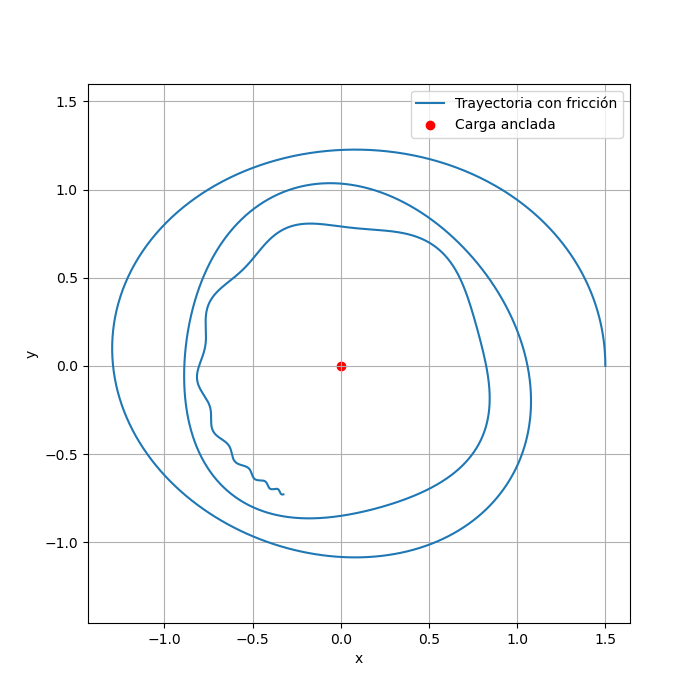

In [8]:
m, k, q_factor = 1.0, 1.0, 0.5
b = 0.1  # Coeficiente de fricción proporcional a la velocidad

def aceleracion_con_friccion(r, v):
    norm_r = np.linalg.norm(r)
    # Fuerza neta: Resorte - Coulomb (repulsiva) - Fricción
    f_total = -k * r + (q_factor / norm_r**3) * r - b * v
    return f_total / m

def rk4_step_fric(r, v, dt):
    k1_v = aceleracion_con_friccion(r, v)
    k1_r = v
    k2_v = aceleracion_con_friccion(r + 0.5*dt*k1_r, v + 0.5*dt*k1_v)
    k2_r = v + 0.5*dt*k1_v
    k3_v = aceleracion_con_friccion(r + 0.5*dt*k2_r, v + 0.5*dt*k2_v)
    k3_r = v + 0.5*dt*k2_v
    k4_v = aceleracion_con_friccion(r + dt*k3_r, v + dt*k3_v)
    k4_r = v + dt*k3_v
    return r + (dt/6)*(k1_r + 2*k2_r + 2*k3_r + k4_r), v + (dt/6)*(k1_v + 2*k2_v + 2*k3_v + k4_v)

r, v = np.array([1.5, 0.0]), np.array([0.0, 1.2])
dt, pasos = 0.01, 5000
trayectoria = []

for _ in range(pasos):
    trayectoria.append(r.copy())
    r, v = rk4_step_fric(r, v, dt)

trayectoria = np.array(trayectoria)
plt.figure(figsize=(7,7))
plt.plot(trayectoria[:,0], trayectoria[:,1], label='Trayectoria con fricción')
plt.scatter(0,0, color='red', label='Carga anclada')
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()

### Ejercicio 3

Variables y constantes:  
Masa de la Tierra ($M_T$): $5.97 \times 10^{24}$ kg.  
Masa de la Luna ($M_L$): $7.34 \times 10^{22}$ kg.  
Distancia Tierra-Luna ($R_{TL}$): $\approx 384,400$ km.  
Velocidaad orbital de la Luna ($\omega$): Determinada por la tercera ley de Kepler.  
La aceleración del satélite $\vec{a}_s$ está dada por:  
$$\vec{a}_s = -G \frac{M_T}{|\vec{r} - \vec{r}_T|^3}(\vec{r} - \vec{r}_T) - G \frac{M_L}{|\vec{r} - \vec{r}_L|^3}(\vec{r} - \vec{r}_L)$$  
Para lograr el "ocho", el satélite debe ser lanzado con una velocidad cercana a la velocidad de escape, pasar por delante de la Luna (en su sentido de movimiento orbital) para que la gravedad lunar frene su momento angular respecto a la Tierra y lo "tire" de vuelta hacia el origen.  

In [ ]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# =========================================================
# CONSTANTES
# =========================================================

G = 6.67430e-11

MT = 5.972e24
ML = 7.342e22

R_TL = 384400000.0
radio_T = 6371000.0
radio_L = 1737000.0

omega = np.sqrt(G*(MT + ML)/R_TL**3)

# =========================================================
# FUNCIONES
# =========================================================

def pos_luna(t):
    return np.array([
        R_TL*np.cos(omega*t),
        R_TL*np.sin(omega*t)
    ])

def aceleracion(t, r):
    rT = r
    rL = r - pos_luna(t)

    dT = np.linalg.norm(rT)
    dL = np.linalg.norm(rL)

    aT = -G*MT*rT/dT**3
    aL = -G*ML*rL/dL**3

    return aT + aL

def rk4_step(t, r, v, dt):
    k1_r = v
    k1_v = aceleracion(t, r)

    k2_r = v + 0.5*dt*k1_v
    k2_v = aceleracion(t + 0.5*dt, r + 0.5*dt*k1_r)

    k3_r = v + 0.5*dt*k2_v
    k3_v = aceleracion(t + 0.5*dt, r + 0.5*dt*k2_r)

    k4_r = v + dt*k3_v
    k4_v = aceleracion(t + dt, r + dt*k3_r)

    r_new = r + (dt/6)*(k1_r + 2*k2_r + 2*k3_r + k4_r)
    v_new = v + (dt/6)*(k1_v + 2*k2_v + 2*k3_v + k4_v)

    return r_new, v_new

def integrar(v0, dt=80, dias=12):
    pasos = int(dias*24*3600/dt)

    r = np.array([radio_T + 200000.0, 0.0])
    v = v0.copy()

    pos_sat = []
    pos_lun = []
    t_arr = []

    for i in range(pasos):
        t = i*dt

        pos_sat.append(r.copy())
        pos_lun.append(pos_luna(t))
        t_arr.append(t)

        r, v = rk4_step(t, r, v, dt)

    return np.array(t_arr), np.array(pos_sat), np.array(pos_lun)

def marco_rotante(t_arr, pos_sat, pos_lun):
    sat_rot = np.zeros_like(pos_sat)
    lun_rot = np.zeros_like(pos_lun)

    for i, t in enumerate(t_arr):
        ang = -omega*t

        R = np.array([
            [np.cos(ang), -np.sin(ang)],
            [np.sin(ang),  np.cos(ang)]
        ])

        sat_rot[i] = R @ pos_sat[i]
        lun_rot[i] = R @ pos_lun[i]

    return sat_rot, lun_rot

# =========================================================
# BÚSQUEDA AUTOMÁTICA DE CONDICIÓN INICIAL
# =========================================================

mejor_score = 1e99
mejor_v0 = None
mejor_datos = None

vx_vals = np.linspace(10600, 11250, 30)
vy_vals = np.linspace(200, 1800, 30)

for vx in vx_vals:
    for vy in vy_vals:

        v0 = np.array([vx, vy])

        t_arr, pos_sat, pos_lun = integrar(v0, dt=120, dias=11)

        dist_luna = np.linalg.norm(pos_sat - pos_lun, axis=1)
        dist_tierra = np.linalg.norm(pos_sat, axis=1)

        min_luna = np.min(dist_luna)

        # Queremos que se acerque a la Luna
        # y luego vuelva cerca de la Tierra después de algunos días
        mitad = len(t_arr)//2
        regreso_tierra = np.min(dist_tierra[mitad:])

        score = min_luna + 0.4*regreso_tierra

        if score < mejor_score:
            mejor_score = score
            mejor_v0 = v0.copy()
            mejor_datos = (t_arr, pos_sat, pos_lun)

print("Mejor condición inicial encontrada:")
print("v0 =", mejor_v0, "m/s")
print("score =", mejor_score)

# =========================================================
# INTEGRACIÓN FINAL CON LA MEJOR CONDICIÓN
# =========================================================

t_arr, pos_sat, pos_lun = integrar(mejor_v0, dt=20, dias=15)

pos_sat_rot, pos_lun_rot = marco_rotante(t_arr, pos_sat, pos_lun)

# =========================================================
# GRÁFICA ESTÁTICA
# =========================================================

fig, ax = plt.subplots(figsize=(9,6))

ax.set_aspect("equal")
ax.grid(True)

ax.set_xlim(-0.25*R_TL, 1.35*R_TL)
ax.set_ylim(-0.75*R_TL, 0.75*R_TL)

ax.set_title("Trayectoria de retorno libre Tierra-Luna")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")

tierra = plt.Circle((0,0), radio_T*2, color="blue", label="Tierra")
luna = plt.Circle((R_TL,0), radio_L*8, color="gray", label="Luna")

ax.add_patch(tierra)
ax.add_patch(luna)

ax.plot([0, R_TL], [0,0], "k--", alpha=0.4)
ax.plot(pos_sat_rot[:,0], pos_sat_rot[:,1], color="orange", lw=2, label="Trayectoria del satélite")

ax.legend()
plt.show()

### Ejercicio Extra

a)  
